In [67]:
import torch
import numpy as np
import pandas as pd
from copy import deepcopy
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [68]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
print(train.shape, test.shape)

(21693, 54) (15004, 53)


In [69]:
train.head()

,ID,X_01,X_02,X_03,X_04,X_05,X_06,X_07,X_08,X_09,...,X_44,X_45,X_46,X_47,X_48,X_49,X_50,X_51,X_52,target
0,TRAIN_00000,0.016,0.242994,0.538536,0.522295,0.374494,0.555348,0.639091,0.494800,0.584233,...,0.435885,0.555359,0.751714,0.376801,0.466993,0.527585,0.598101,0.312160,0.582797,0
1,TRAIN_00001,0.019,0.240380,0.517223,0.538976,0.371149,0.693825,0.663667,0.530931,0.577200,...,0.479859,0.693855,0.748955,0.356118,0.613461,0.508069,0.569814,0.313351,0.570513,20
2,TRAIN_00002,0.012,0.248946,0.547109,0.466713,0.415830,0.656887,0.681782,0.580773,0.527069,...,0.416115,0.656884,0.750059,0.417200,0.525393,0.551947,0.639860,0.342627,0.573139,1
3,TRAIN_00003,0.013,0.245877,0.527870,0.515534,0.379199,0.594391,0.663816,0.494931,0.581796,...,0.436761,0.594364,0.746297,0.374659,0.694290,0.532705,0.581142,0.316417,0.562656,19
4,TRAIN_00004,0.024,0.239237,0.566087,0.514384,0.378451,0.610543,0.644811,0.508567,0.593614,...,0.422407,0.610526,0.749565,0.372742,0.565549,0.535573,0.580484,0.314982,0.591692,15


In [70]:
train.columns
assert "target" in train.columns, "CSV에 target 열이 있어야 합니다."
print(train.columns)

Index(['ID', 'X_01', 'X_02', 'X_03', 'X_04', 'X_05', 'X_06', 'X_07', 'X_08',
       'X_09', 'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15', 'X_16', 'X_17',
       'X_18', 'X_19', 'X_20', 'X_21', 'X_22', 'X_23', 'X_24', 'X_25', 'X_26',
       'X_27', 'X_28', 'X_29', 'X_30', 'X_31', 'X_32', 'X_33', 'X_34', 'X_35',
       'X_36', 'X_37', 'X_38', 'X_39', 'X_40', 'X_41', 'X_42', 'X_43', 'X_44',
       'X_45', 'X_46', 'X_47', 'X_48', 'X_49', 'X_50', 'X_51', 'X_52',
       'target'],
      dtype='object')


In [71]:
def process_df(df: pd.DataFrame) -> pd.DataFrame:

    # 불필요한 ID 열 제거
    if "ID" in df.columns:
        df_copy = df.drop('ID', axis=1)
    else:
        df_copy = deepcopy(df)

    return df_copy

In [72]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21693 entries, 0 to 21692
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      21693 non-null  object 
 1   X_01    21693 non-null  float64
 2   X_02    21693 non-null  float64
 3   X_03    21693 non-null  float64
 4   X_04    21693 non-null  float64
 5   X_05    21693 non-null  float64
 6   X_06    21693 non-null  float64
 7   X_07    21693 non-null  float64
 8   X_08    21693 non-null  float64
 9   X_09    21693 non-null  float64
 10  X_10    21693 non-null  float64
 11  X_11    21693 non-null  float64
 12  X_12    21693 non-null  float64
 13  X_13    21693 non-null  float64
 14  X_14    21693 non-null  float64
 15  X_15    21693 non-null  float64
 16  X_16    21693 non-null  float64
 17  X_17    21693 non-null  float64
 18  X_18    21693 non-null  float64
 19  X_19    21693 non-null  float64
 20  X_20    21693 non-null  float64
 21  X_21    21693 non-null  float64
 22

In [73]:
train.describe()

,X_01,X_02,X_03,X_04,X_05,X_06,X_07,X_08,X_09,X_10,...,X_44,X_45,X_46,X_47,X_48,X_49,X_50,X_51,X_52,target
count,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,...,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.00000
mean,0.017989,0.258061,0.533411,0.510776,0.421508,0.600059,0.618569,0.534465,0.550514,0.517199,...,0.453256,0.600050,0.731735,0.408285,0.477403,0.520059,0.582188,0.359334,0.571657,10.00000
std,0.004794,0.064098,0.057962,0.082500,0.168995,0.082645,0.139561,0.153934,0.134451,0.092376,...,0.072222,0.082649,0.085227,0.137385,0.072804,0.099855,0.065809,0.163723,0.070578,6.05544
min,-0.003000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.015000,0.244223,0.510506,0.507370,0.363789,0.555003,0.642250,0.480822,0.562856,0.463122,...,0.427448,0.554991,0.739806,0.367151,0.432446,0.511138,0.576432,0.306199,0.559780,5.00000
50%,0.018000,0.247364,0.535398,0.520045,0.378157,0.604917,0.653100,0.504495,0.578888,0.520103,...,0.442839,0.604909,0.746572,0.379901,0.477400,0.525908,0.589860,0.317177,0.579899,10.00000
75%,0.021000,0.251002,0.560651,0.533285,0.393900,0.651660,0.662580,0.540172,0.593727,0.578334,...,0.459141,0.651646,0.752450,0.394756,0.523216,0.539435,0.601181,0.329355,0.597964,15.00000
max,0.037000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.00000


In [74]:
train = process_df(train)
train.head()

,X_01,X_02,X_03,X_04,X_05,X_06,X_07,X_08,X_09,X_10,...,X_44,X_45,X_46,X_47,X_48,X_49,X_50,X_51,X_52,target
0,0.016,0.242994,0.538536,0.522295,0.374494,0.555348,0.639091,0.494800,0.584233,0.595353,...,0.435885,0.555359,0.751714,0.376801,0.466993,0.527585,0.598101,0.312160,0.582797,0
1,0.019,0.240380,0.517223,0.538976,0.371149,0.693825,0.663667,0.530931,0.577200,0.617395,...,0.479859,0.693855,0.748955,0.356118,0.613461,0.508069,0.569814,0.313351,0.570513,20
2,0.012,0.248946,0.547109,0.466713,0.415830,0.656887,0.681782,0.580773,0.527069,0.337828,...,0.416115,0.656884,0.750059,0.417200,0.525393,0.551947,0.639860,0.342627,0.573139,1
3,0.013,0.245877,0.527870,0.515534,0.379199,0.594391,0.663816,0.494931,0.581796,0.598036,...,0.436761,0.594364,0.746297,0.374659,0.694290,0.532705,0.581142,0.316417,0.562656,19
4,0.024,0.239237,0.566087,0.514384,0.378451,0.610543,0.644811,0.508567,0.593614,0.646513,...,0.422407,0.610526,0.749565,0.372742,0.565549,0.535573,0.580484,0.314982,0.591692,15


target
0     1033
4     1033
17    1033
9     1033
2     1033
10    1033
6     1033
13    1033
11    1033
5     1033
3     1033
20    1033
18    1033
14    1033
12    1033
16    1033
8     1033
15    1033
19    1033
1     1033
7     1033
Name: count, dtype: int64


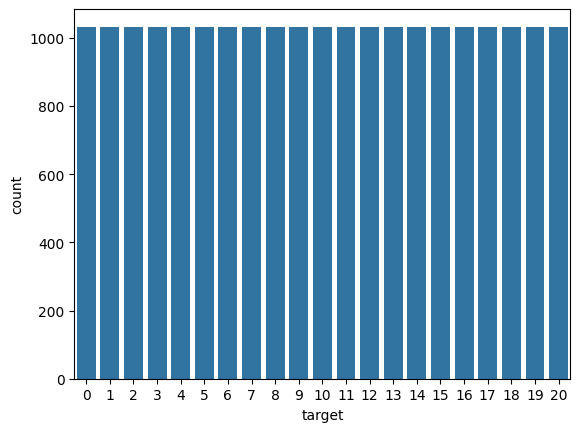

In [75]:
sns.countplot(data=train, x='target')
print(train['target'].value_counts()) # label은 0 ~ 20까지 있으면 1033개로 균등 분포

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred, average='macro')
    recall = recall_score(y_test , pred, average='macro')
    f1 = f1_score(y_test,pred, average='macro')
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba, multi_class='ovr')
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [77]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve

X = train.drop('target', axis=1)
y = train['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

model = LGBMClassifier(n_estimators=1000, learning_rate=0.05, random_state=42, min_child_samples=20, early_stopping_rounds=50)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])

[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000809 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13043
[LightGBM] [Info] Number of data points in the train set: 15618, number of used features: 52
[LightGBM] [Warning] early_stopping_round is set=50, early_stopping_rounds=50 will be ignored. Current value: early_stopping_round=50
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.044138
[LightGBM] [Info] Start training from score -3.045483
[LightGBM]

LGBMClassifier(early_stopping_rounds=50, learning_rate=0.05, n_estimators=1000,
               random_state=42)

In [78]:
preds = model.predict(X_test)
pred_proba = model.predict_proba(X_test)
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[ 42   0   0  21   0   0   0   0   0  59   2   0   0   0   3  59   1   0
    0  19   0]
 [  0 206   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0]
 [  0   0 207   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0]
 [ 28   0   0 108   0   0   0   0   0  33   1   1   0   0   2  15   2   0
    0  16   0]
 [  0   0   0   0 206   0   0   0   0   0   0   1   0   0   0   0   0   0
    0   0   0]
 [  0   0   0   0   0 206   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0]
 [  0   0   0   0   0   0 207   0   0   0   0   0   0   0   0   0   0   0
    0   0   0]
 [  0   0   0   0   0   0   0 207   0   0   0   0   0   0   0   0   0   0
    0   0   0]
 [  0   0   0   0   0   0   0   0 193   0   2   0   7   4   0   0   0   0
    0   0   0]
 [ 44   0   0  34   0   0   0   0   0  50   5   0   0   0   4  54   1   0
    0  15   0]
 [  2   0   0   4   0   0   0   0   0   6 181   0   2   0   0   6   3   0
    0   3   0]
 [  1   0   0  

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

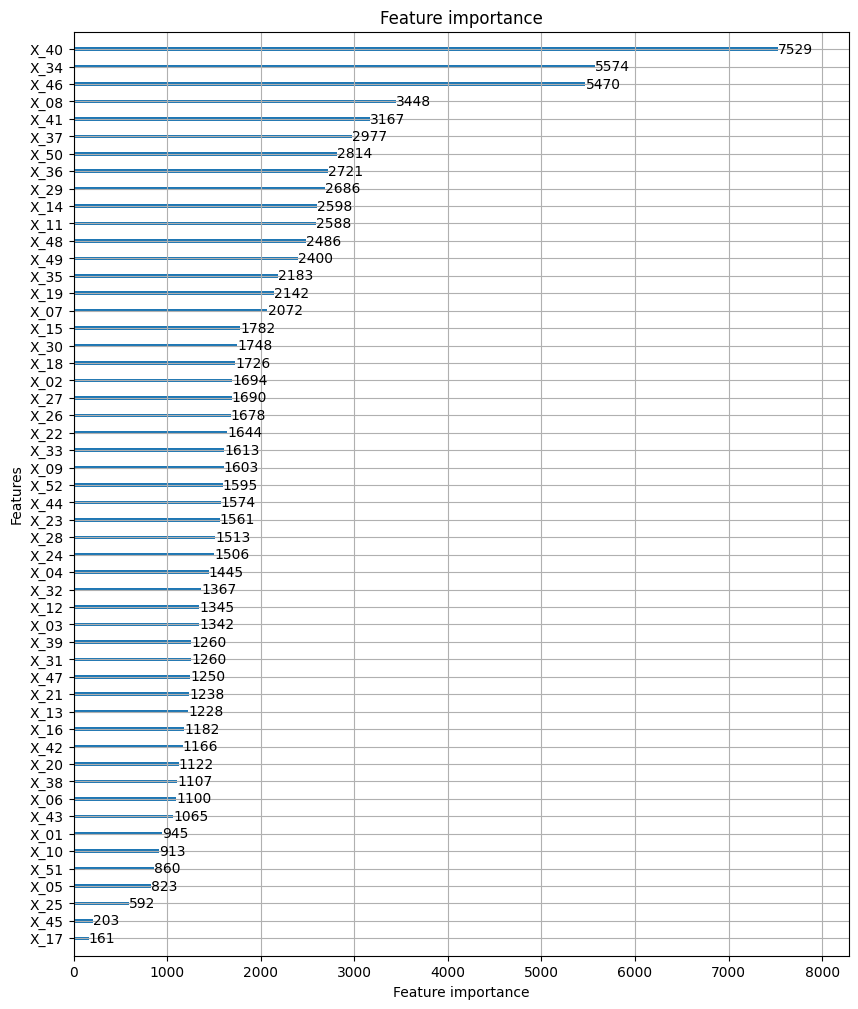

In [79]:
from lightgbm import plot_importance

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model, ax=ax)

In [80]:
importances = model.feature_importances_
feature_importance  = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)[:20].index
print(feature_importance)

Index(['X_40', 'X_34', 'X_46', 'X_08', 'X_41', 'X_37', 'X_50', 'X_36', 'X_29',
       'X_14', 'X_11', 'X_48', 'X_49', 'X_35', 'X_19', 'X_07', 'X_15', 'X_30',
       'X_18', 'X_02'],
      dtype='object')


In [81]:
train = process_df(train)
train.head()

print(feature_importance)
X = train[feature_importance]
y = train['target']

X.head()


Index(['X_40', 'X_34', 'X_46', 'X_08', 'X_41', 'X_37', 'X_50', 'X_36', 'X_29',
       'X_14', 'X_11', 'X_48', 'X_49', 'X_35', 'X_19', 'X_07', 'X_15', 'X_30',
       'X_18', 'X_02'],
      dtype='object')


,X_40,X_34,X_46,X_08,X_41,X_37,X_50,X_36,X_29,X_14,X_11,X_48,X_49,X_35,X_19,X_07,X_15,X_30,X_18,X_02
0,40.965,0.479050,0.751714,0.494800,0.770997,22.295,0.598101,0.607972,0.541863,0.363647,18.160,0.466993,0.527585,0.450727,47.566,0.639091,0.590812,0.556272,0.365435,0.242994
1,41.140,0.497632,0.748955,0.530931,0.774295,21.067,0.569814,0.612235,0.574415,0.374075,18.519,0.613461,0.508069,0.450575,52.040,0.663667,0.561319,0.549338,0.379645,0.240380
2,40.951,0.462423,0.750059,0.580773,0.759663,23.551,0.639860,0.566747,0.666574,0.232461,17.971,0.525393,0.551947,0.384833,59.204,0.681782,0.605941,0.568189,0.302963,0.248946
3,41.356,0.543937,0.746297,0.494931,0.783498,22.101,0.581142,0.616384,0.544801,0.371687,18.168,0.694290,0.532705,0.440386,47.758,0.663816,0.571503,0.559318,0.376450,0.245877
4,41.056,0.489682,0.749565,0.508567,0.784144,22.506,0.580484,0.614796,0.561517,0.369583,17.845,0.565549,0.535573,0.429509,49.241,0.644811,0.524823,0.567187,0.373042,0.239237


In [82]:
X.describe()

,X_40,X_34,X_46,X_08,X_41,X_37,X_50,X_36,X_29,X_14,X_11,X_48,X_49,X_35,X_19,X_07,X_15,X_30,X_18,X_02
count,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000,21693.000000
mean,42.253450,0.496832,0.731735,0.534465,0.757960,23.399720,0.582188,0.636854,0.564430,0.378673,18.918073,0.477403,0.520059,0.438482,50.956294,0.618569,0.556958,0.541562,0.385823,0.258061
std,11.540643,0.070228,0.085227,0.153934,0.100947,12.815777,0.065809,0.078670,0.097198,0.078478,5.059086,0.072804,0.099855,0.094610,17.774983,0.139561,0.080348,0.129341,0.135133,0.064098
min,-0.143000,0.000000,0.000000,0.000000,0.000000,-0.099000,0.000000,0.000000,0.000000,0.000000,-0.004000,0.000000,0.000000,0.000000,-0.235000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.956000,0.480839,0.739806,0.480822,0.769803,21.576000,0.576432,0.609522,0.529993,0.361728,17.851000,0.432446,0.511138,0.420435,45.703000,0.642250,0.516804,0.545210,0.358743,0.244223
50%,41.177000,0.496605,0.746572,0.504495,0.778755,22.148000,0.589860,0.613535,0.556061,0.371709,18.155000,0.477400,0.525908,0.436163,48.602000,0.653100,0.555396,0.555236,0.370589,0.247364
75%,41.546000,0.512537,0.752450,0.540172,0.785845,22.642000,0.601181,0.619503,0.597514,0.384795,18.497000,0.523216,0.539435,0.452718,52.716000,0.662580,0.597109,0.565819,0.380704,0.251002
max,100.210000,1.000000,1.000000,1.000000,1.000000,100.098000,1.000000,1.000000,1.000000,1.000000,92.050000,1.000000,1.000000,1.000000,100.241000,1.000000,1.000000,1.000000,1.000000,1.000000


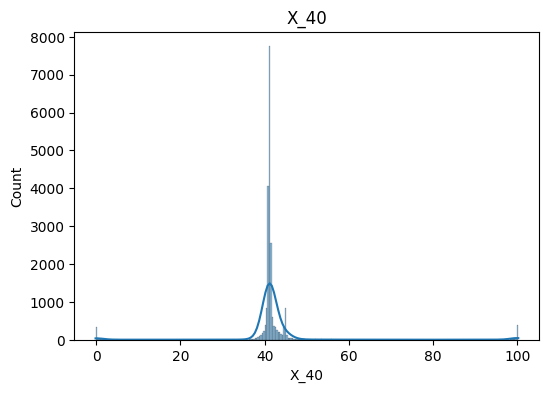

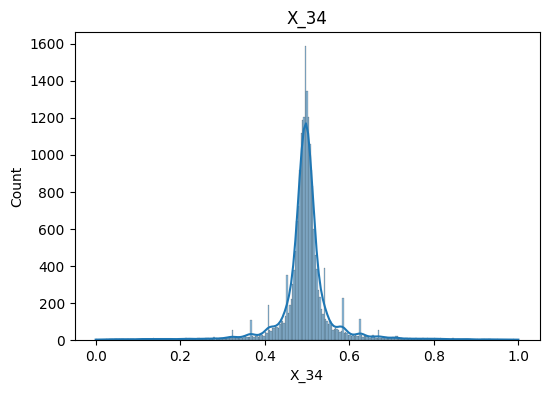

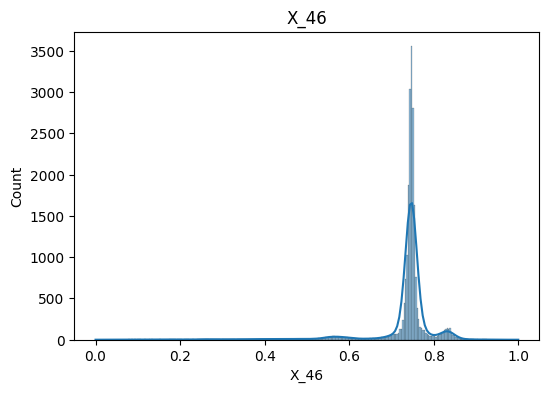

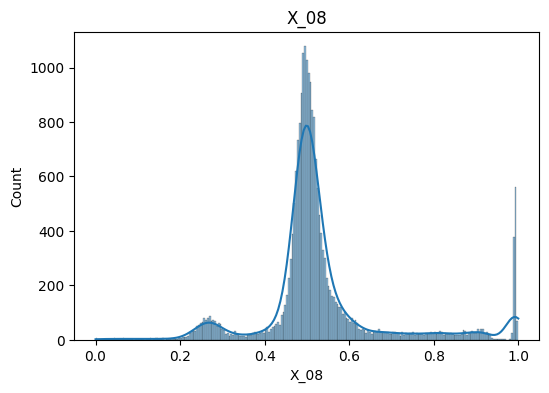

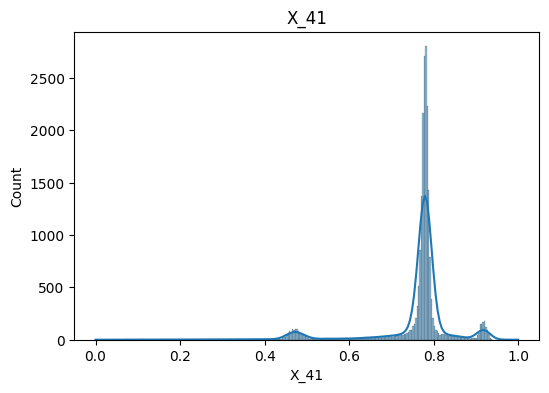

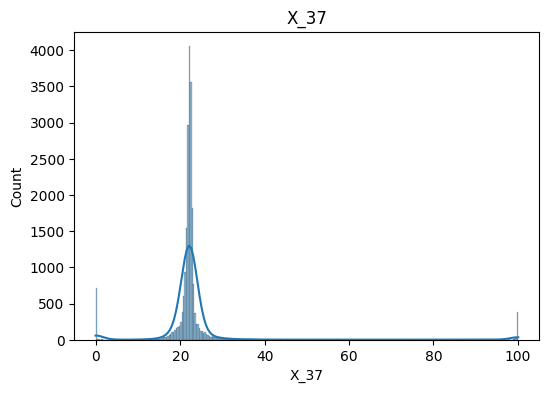

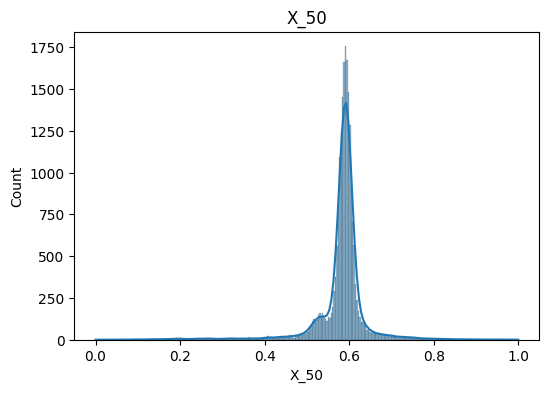

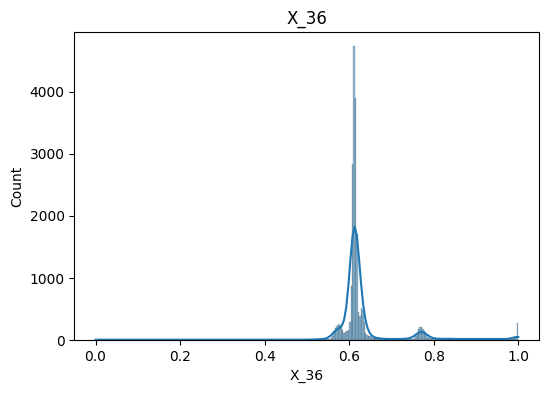

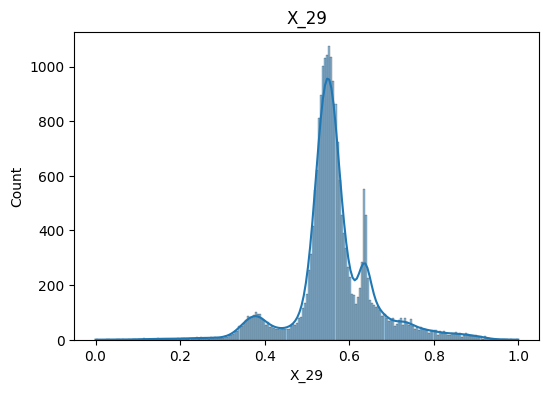

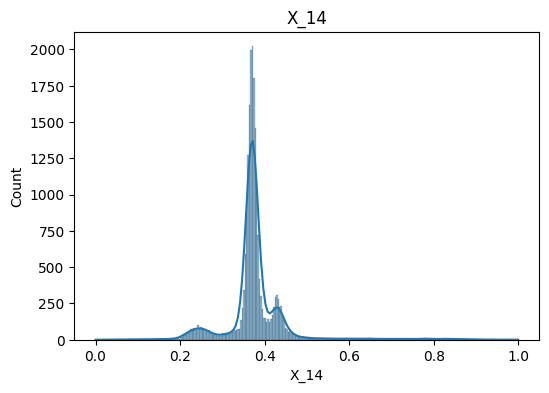

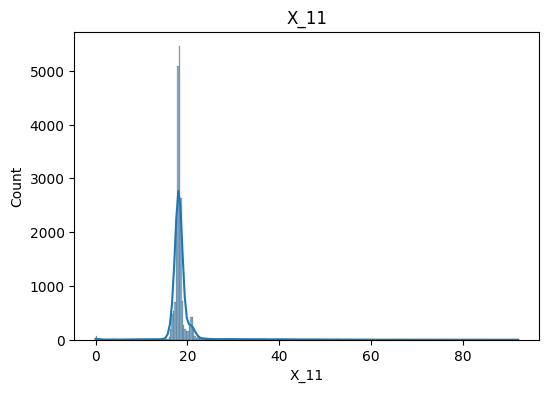

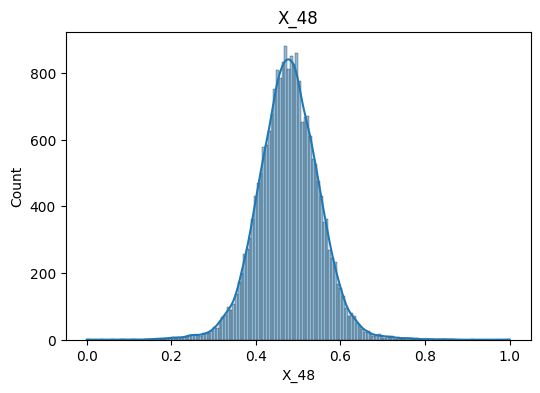

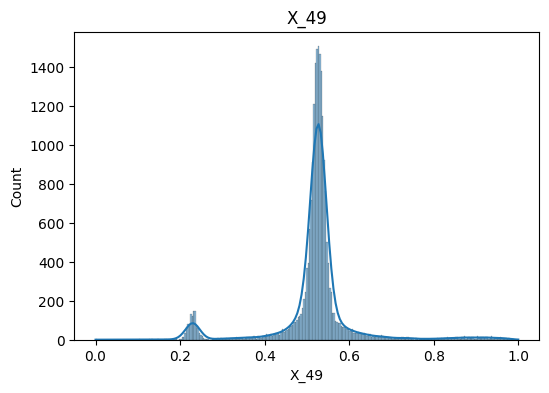

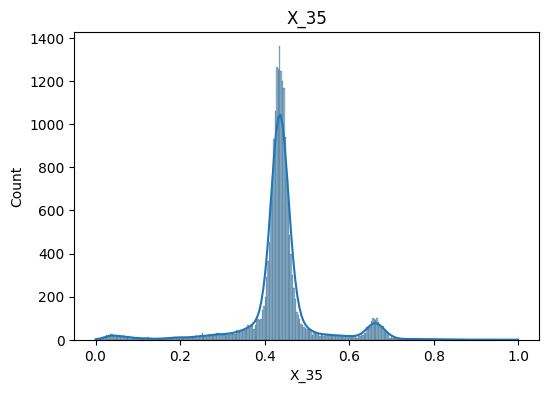

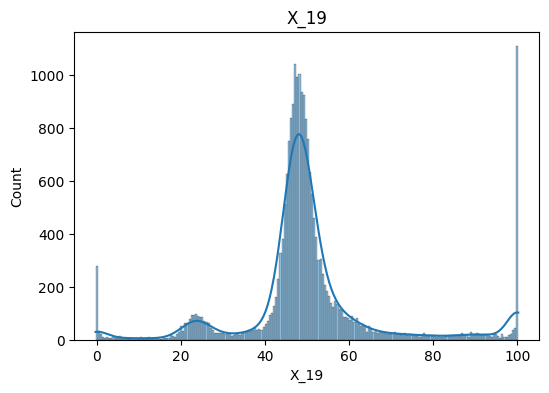

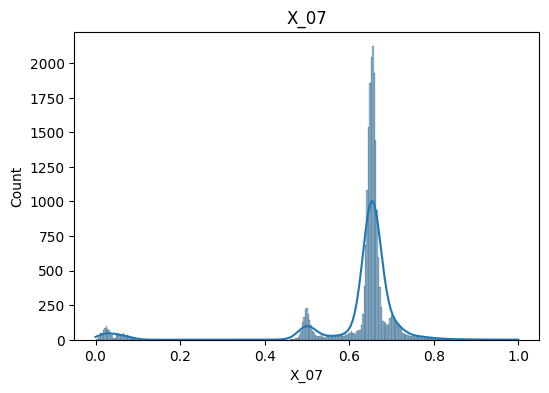

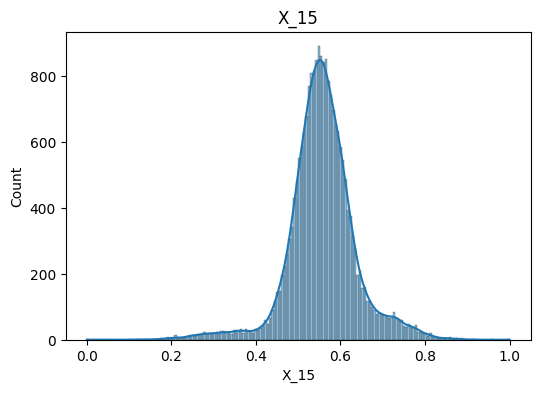

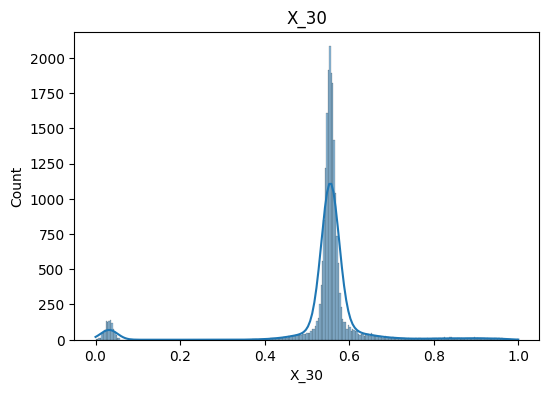

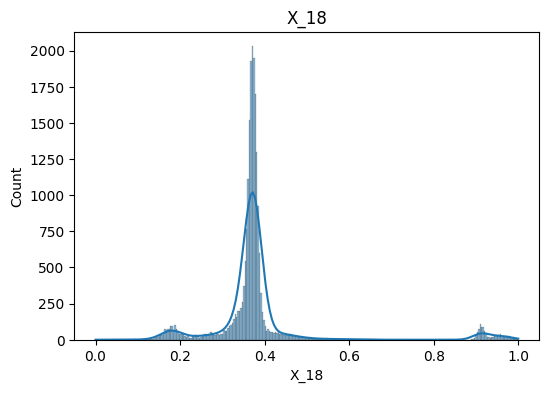

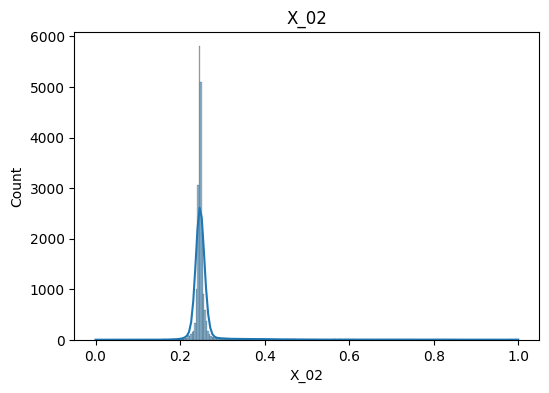

In [83]:
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=X, x=col, kde=True)
    plt.title(col)
    plt.show()

In [84]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,X_40,X_34,X_46,X_08,X_41,X_37,X_50,X_36,X_29,X_14,X_11,X_48,X_49,X_35,X_19,X_07,X_15,X_30,X_18,X_02
0,-0.111647,-0.253212,0.234436,-0.257678,0.129146,-0.086202,0.241814,-0.367141,-0.232186,-0.191463,-0.149847,-0.142992,0.075363,0.129435,-0.190738,0.147050,0.421350,0.113740,-0.150878,-0.235072
1,-0.096483,0.011385,0.202054,-0.022957,0.161818,-0.182024,-0.188043,-0.312945,0.102726,-0.058584,-0.078884,1.868857,-0.120076,0.127824,0.060969,0.323148,0.054276,0.060126,-0.045718,-0.275860
2,-0.112860,-0.489980,0.215014,0.300836,0.016862,0.011804,0.876373,-0.891171,1.050907,-1.863131,-0.187207,0.659183,0.319343,-0.567060,0.464017,0.452951,0.609658,0.205875,-0.613188,-0.142217
3,-0.077766,0.670753,0.170875,-0.256825,0.252983,-0.101340,-0.015900,-0.260211,-0.201958,-0.089016,-0.148266,2.979111,0.126641,0.020134,-0.179936,0.324215,0.181033,0.137289,-0.069363,-0.190086
4,-0.103762,-0.101811,0.209215,-0.168244,0.259388,-0.069738,-0.025894,-0.280399,-0.029978,-0.115829,-0.212113,1.210755,0.155366,-0.094844,-0.096503,0.188036,-0.399959,0.198126,-0.094581,-0.293691


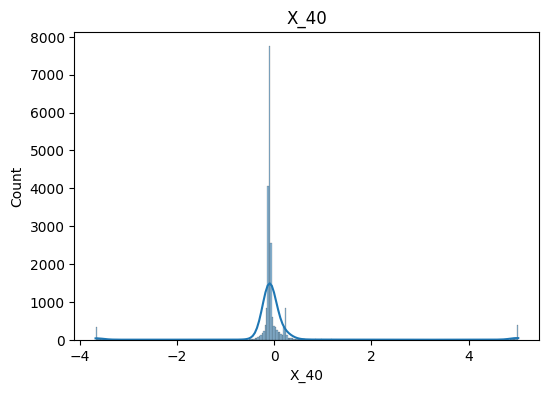

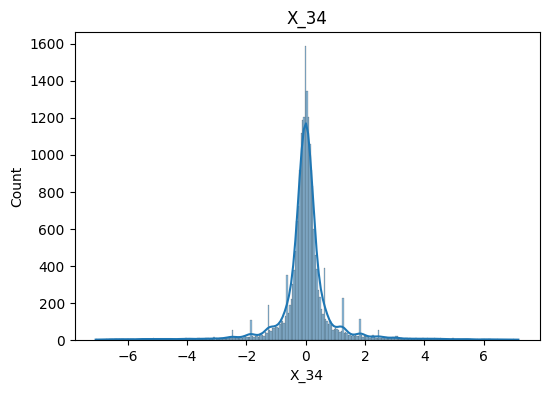

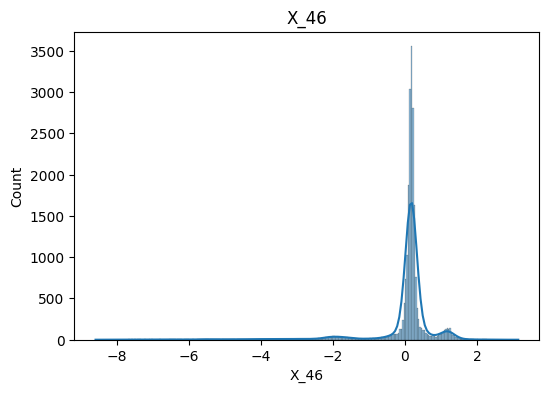

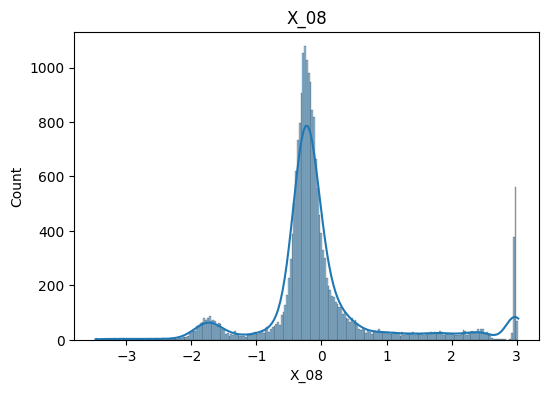

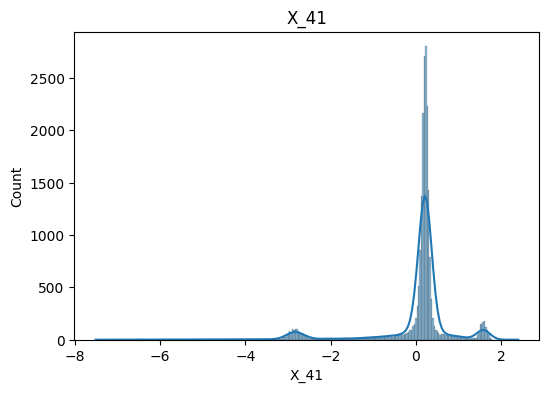

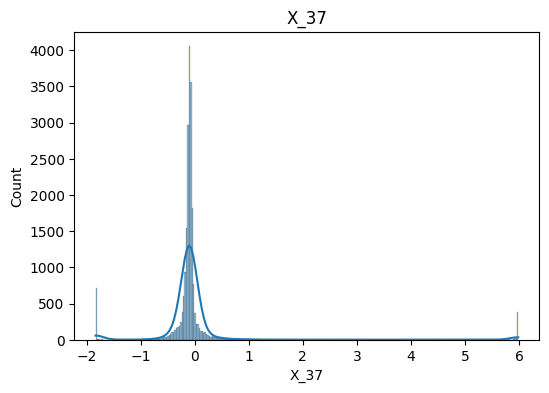

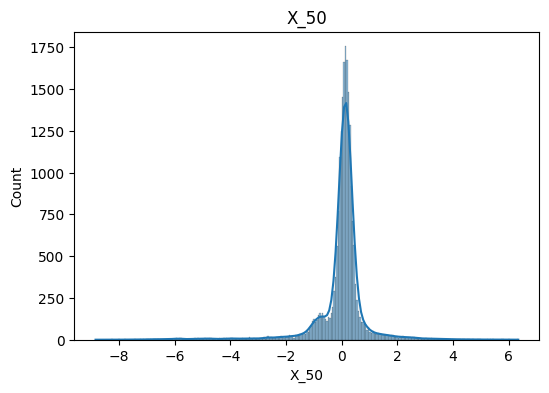

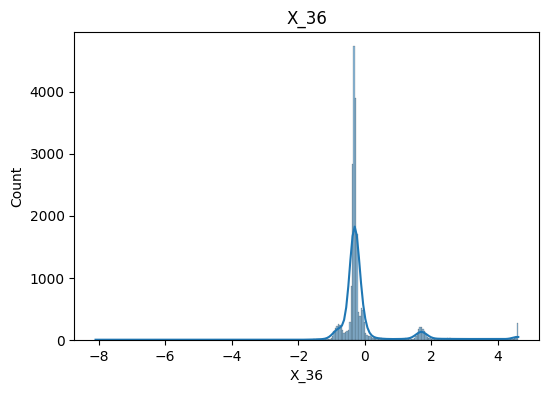

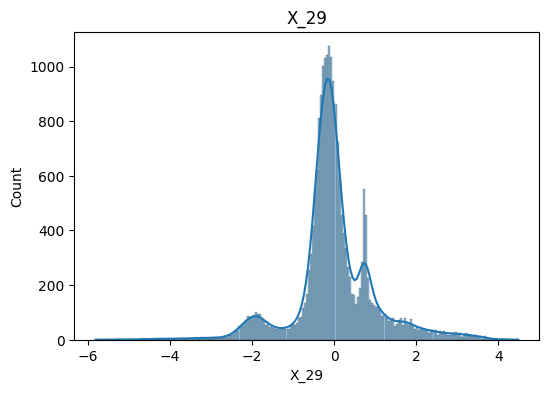

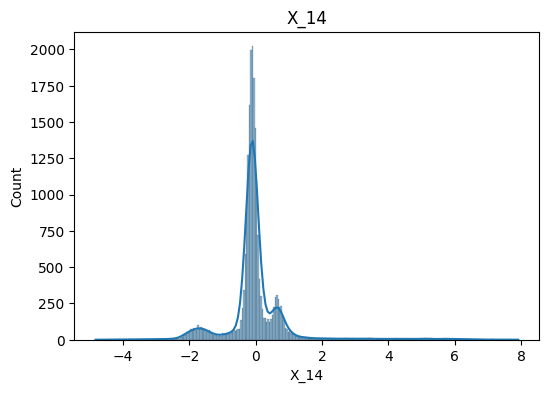

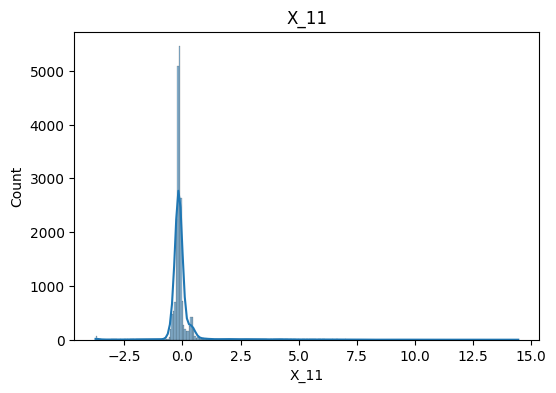

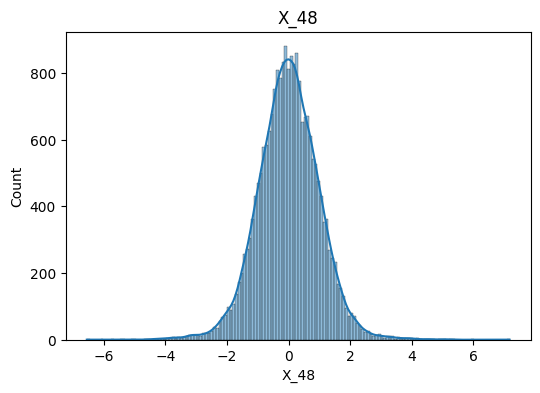

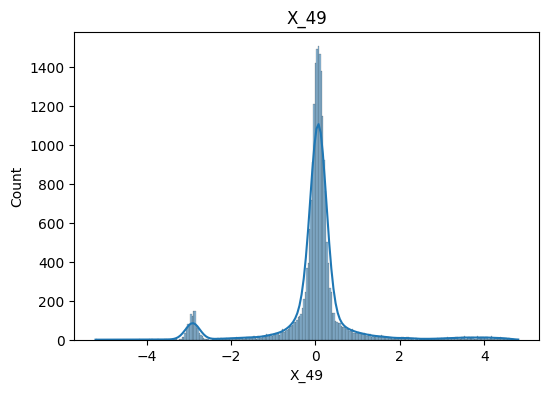

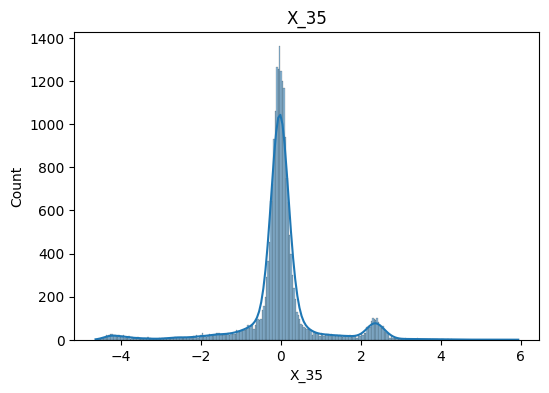

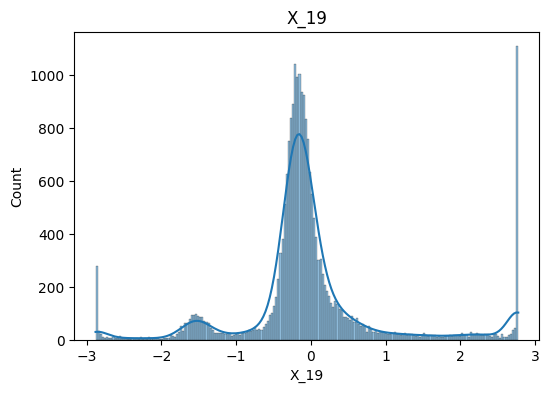

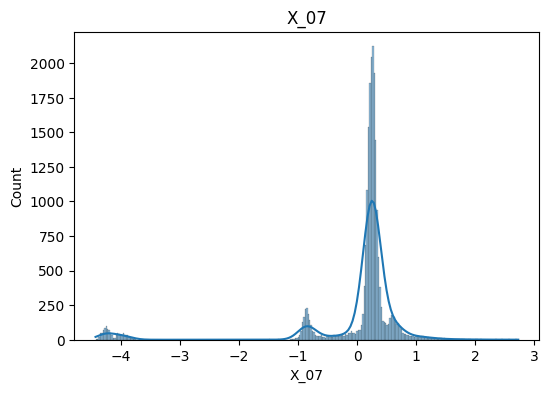

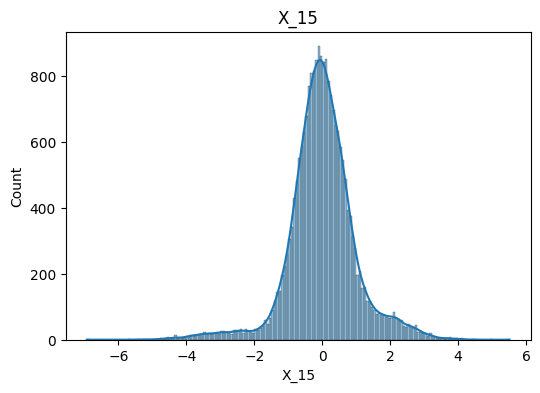

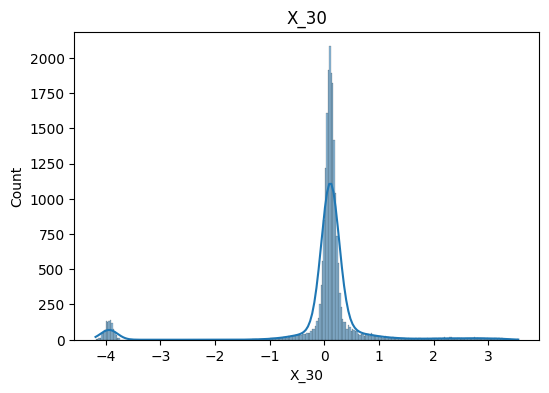

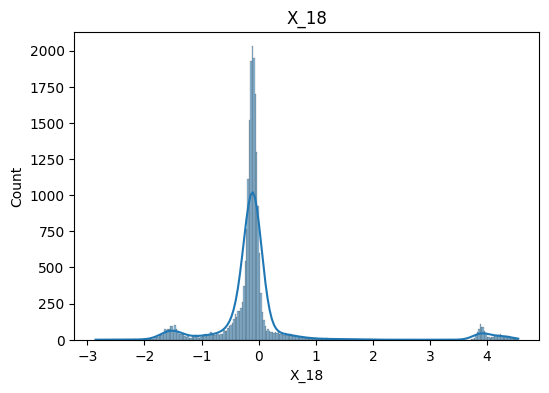

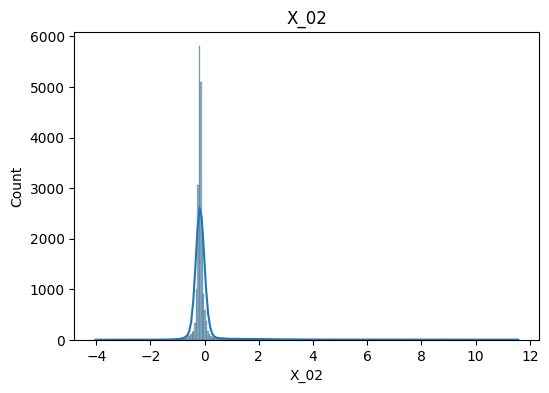

In [85]:
for col in X_scaled.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=X_scaled, x=col, kde=True)
    plt.title(col)
    plt.show()

In [86]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import train_test_split

device = torch.device("mps" if torch.mps.is_available() else "cpu")
torch.manual_seed(42)
print(device)

mps


In [111]:
len(y.value_counts())

21

In [112]:
y.values

array([ 0, 20,  1, ...,  5,  3, 17], shape=(21693,))

In [113]:
# Step 1. numpy -> Tensor 변환

X_torch = torch.tensor(X_scaled.values, dtype=torch.float32)
y_torch = torch.tensor(y.values, dtype=torch.long)


# Step 2. 전체 Dataset 만들기
full_dataset = TensorDataset(X_torch, y_torch)

# Step 3. train/test 분할

train_idx, test_idx, y_train, y_test = train_test_split(range(len(y)), y, stratify=y, test_size=0.2, random_state=42)

# Step 4. train/val 분할

train_idx, valid_idx, _, _ = train_test_split(train_idx, y_train, stratify=y_train, test_size=0.1, random_state=42)

# Step 5. Subset 으로 최종 Dataset 생성

train_dataset = Subset(full_dataset, train_idx)
valdation_dataset = Subset(full_dataset, valid_idx)
test_dataset = Subset(full_dataset, test_idx)

print(len(train_dataset), len(valdation_dataset), len(test_dataset))

# Step 6. batch_size 만큼 나누기

BATCH_SIZE = 128

train_batches = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
valid_batches = DataLoader(valdation_dataset, BATCH_SIZE , shuffle=False)
test_batches = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

15618 1736 4339


In [114]:
print(X_torch.size(), y_torch.size())

torch.Size([21693, 20]) torch.Size([21693])


#### 모델 선언 및 생성

In [128]:

class FaultDetectionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear_layer = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        y = self.linear_layer(x)
        return y

minibatch_size = 128
input_dim = X_torch.size(-1) # 20
output_dim = len(y_torch.unique())
print(input_dim, output_dim)
model = FaultDetectionNet(input_dim, output_dim)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

20 21


In [129]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[-0.1619, -0.0327,  0.1326,  ...,  0.0204, -0.1246, -0.0895],
        [ 0.1333, -0.1331,  0.1892,  ..., -0.0778,  0.1981, -0.0499],
        [-0.1493,  0.0534, -0.0028,  ..., -0.1869, -0.1123, -0.0421],
        ...,
        [ 0.1713,  0.2062, -0.2128,  ..., -0.0031,  0.1428,  0.0021],
        [ 0.1083, -0.1579, -0.1056,  ..., -0.2236,  0.1986, -0.0746],
        [ 0.0870,  0.0638,  0.0480,  ...,  0.2090,  0.2060, -0.1593]],
       requires_grad=True)
Parameter containing:
tensor([ 1.3941e-01, -1.3523e-01, -1.4536e-01,  1.5697e-01, -2.2249e-01,
        -1.0285e-01,  6.7433e-02,  1.9363e-01, -6.1824e-02,  1.4216e-01,
        -1.8360e-01, -1.0007e-01,  1.9173e-01, -2.0409e-02,  1.8695e-01,
        -5.2898e-02, -4.7032e-02, -1.9246e-01,  1.6092e-01, -8.2920e-03,
        -1.6824e-02,  1.9984e-01,  8.5768e-02,  1.4252e-01,  2.1550e-02,
        -2.4415e-02,  1.7288e-01,  1.9395e-02, -4.2318e-02,  5.0742e-02,
        -2.7583e-02, -2.1606e-01,  9.7968e-02, -8.9710e-0

In [130]:
import torch
import time
import numpy as np
from copy import deepcopy

def train_model(model, loss_func, optimizer, train_loader, valid_loader,
                scheduler=None, early_stop=10, epochs=50, device="cpu"):
    
    model = model.to(device)
    
    train_losses, valid_losses = [], []
    train_accuracies, valid_accuracies = [], []
    best_model_wts = deepcopy(model.state_dict())
    lowest_loss = np.inf
    lowest_epoch = 0
    
    for epoch in range(epochs):
        start = time.time()
        
        # === Train ===
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)                # (batch, num_classes)
            loss = loss_func(outputs, y_batch)      # CrossEntropyLoss
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)    # 다중 분류 예측
            running_corrects += torch.sum(preds == y_batch).item()
            total += y_batch.size(0)
        
        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # === Validation ===
        model.eval()
        valid_running_loss, valid_corrects, total_val = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_func(outputs, y_batch)
                
                valid_running_loss += loss.item() * X_batch.size(0)
                preds = torch.argmax(outputs, dim=1)
                valid_corrects += torch.sum(preds == y_batch).item()
                total_val += y_batch.size(0)
        
        valid_loss = valid_running_loss / total_val
        valid_acc = valid_corrects / total_val
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_acc)
        
        if scheduler:
            scheduler.step(valid_loss)
        
        # === Early Stopping 체크 ===
        if valid_loss < lowest_loss:
            lowest_loss = valid_loss
            lowest_epoch = epoch
            best_model_wts = deepcopy(model.state_dict())
        elif early_stop > 0 and epoch - lowest_epoch >= early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        elapsed = time.time() - start
        print(f"Epoch {epoch+1}/{epochs} | {elapsed:.1f}s")
        print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"  Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, train_losses, train_accuracies, valid_losses, valid_accuracies

In [132]:
trained_model, train_losses, train_accs, valid_losses, valid_accs = train_model(
    model, loss_func, optimizer,
    train_batches, valid_batches,
    scheduler=None,
    early_stop=10,
    epochs=100,
    device=device
)

Epoch 1/100 | 0.5s
  Train Loss: 2.3207 | Train Acc: 0.8049
  Valid Loss: 2.3317 | Valid Acc: 0.7926
Epoch 2/100 | 0.5s
  Train Loss: 2.3226 | Train Acc: 0.8028
  Valid Loss: 2.3311 | Valid Acc: 0.7915
Epoch 3/100 | 0.5s
  Train Loss: 2.3203 | Train Acc: 0.8052
  Valid Loss: 2.3259 | Valid Acc: 0.7995
Epoch 4/100 | 0.5s
  Train Loss: 2.3222 | Train Acc: 0.8030
  Valid Loss: 2.3302 | Valid Acc: 0.7944
Epoch 5/100 | 0.5s
  Train Loss: 2.3176 | Train Acc: 0.8085
  Valid Loss: 2.3330 | Valid Acc: 0.7874
Epoch 6/100 | 0.5s
  Train Loss: 2.3177 | Train Acc: 0.8059
  Valid Loss: 2.3297 | Valid Acc: 0.7932
Epoch 7/100 | 0.5s
  Train Loss: 2.3178 | Train Acc: 0.8061
  Valid Loss: 2.3325 | Valid Acc: 0.7886
Epoch 8/100 | 0.5s
  Train Loss: 2.3179 | Train Acc: 0.8059
  Valid Loss: 2.3297 | Valid Acc: 0.7944
Epoch 9/100 | 0.5s
  Train Loss: 2.3160 | Train Acc: 0.8091
  Valid Loss: 2.3307 | Valid Acc: 0.7892
Epoch 10/100 | 0.5s
  Train Loss: 2.3187 | Train Acc: 0.8062
  Valid Loss: 2.3267 | Valid A

In [133]:
test_loss = 0.0
correct = 0
wrong_samples, wrong_preds, actual_preds = [], [], []

model.eval()
with torch.no_grad():
    for x_minibatch, y_minibatch in test_batches:
        x_minibatch = x_minibatch.to(device)
        y_minibatch = y_minibatch.to(device)

        # forward
        y_test_pred = model(x_minibatch)

        # 손실
        loss = loss_func(y_test_pred, y_minibatch)
        test_loss += loss.item() * x_minibatch.size(0)  # 배치 크기 반영해서 합산

        # 예측
        pred = torch.argmax(y_test_pred, dim=1)
        correct += (pred == y_minibatch).sum().item()

        # 오답 샘플 저장
        wrong_idx = (pred != y_minibatch).nonzero(as_tuple=True)[0].cpu().numpy().tolist()
        for index in wrong_idx:
            wrong_samples.append(x_minibatch[index].cpu())
            wrong_preds.append(pred[index].cpu())
            actual_preds.append(y_minibatch[index].cpu())

# 평균 손실
test_loss /= len(test_batches.dataset)

# 정확도
accuracy = 100. * correct / len(test_batches.dataset)

print('Average Test Loss: {:.4f}'.format(test_loss))
print('Accuracy: {}/{} ({:.2f}%)'.format(
    correct, len(test_batches.dataset), accuracy
))

Average Test Loss: 2.3311
Accuracy: 3434/4339 (79.14%)


In [134]:
# Generate submission file using the trained model
# Load test data and keep ID for submission
test_df = pd.read_csv('./data/test.csv')
sample_ids = test_df['ID']

# Apply the same preprocessing and feature selection
test_processed = process_df(test_df)
test_selected = test_processed[feature_importance]

# Use the fitted scaler from training
test_scaled = scaler.transform(test_selected)
test_tensor = torch.tensor(test_scaled, dtype=torch.float32).to(device)

# Use the trained model (fall back to `model` if needed)
inference_model = trained_model if 'trained_model' in globals() else model
inference_model.eval()
with torch.no_grad():
    logits = inference_model(test_tensor)
    test_preds = torch.argmax(logits, dim=1).cpu().numpy()

submission = pd.DataFrame({'ID': sample_ids, 'target': test_preds})
submission_path = './data/submission.csv'
submission.to_csv(submission_path, index=False)
print(f'Saved submission to {submission_path}')
submission.head()

Saved submission to ./data/submission.csv


,ID,target
0,TEST_00000,4
1,TEST_00001,5
2,TEST_00002,0
3,TEST_00003,3
4,TEST_00004,0
